In [1]:
# 1. Imports

# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import matplotlib for plot customization
import matplotlib as m

# Import seaborn for statistical visualization
import seaborn as sns

# Import statsmodels for statistical modeling
import statsmodels.api as sm

# Import seasonal_decompose for time-series analysis
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
#testing things

In [3]:
# 2. Formatting Graph Outputs

# Set Matplotlib to default style for a minimalist look
plt.style.use('default')

# Allow all columns to display without truncation
pd.set_option('display.max_columns', 500)

# Auto-adjust pandas display width for readability
pd.set_option('display.width', None)

# Set default figure size for visible graphs
m.rcParams['figure.figsize'] = (12, 6)

# Set font size for axis labels and tick labels
m.rcParams['axes.labelsize'] = 12
m.rcParams['xtick.labelsize'] = 10
m.rcParams['ytick.labelsize'] = 10

# Make axis titles bold for emphasis
m.rcParams['axes.titleweight'] = 'bold'

# Ensure text color is black for readability
m.rcParams['text.color'] = 'black'

# Increase line width for better visibility
m.rcParams['lines.linewidth'] = 2

# Set axis lines: thin, light gray for subtlety
m.rcParams['axes.axisbelow'] = True
m.rcParams['axes.grid'] = False
m.rcParams['axes.linewidth'] = 0.8
m.rcParams['axes.edgecolor'] = 'gray'

# Add custom grid: light gray, dotted, thin lines
m.rcParams['grid.color'] = 'gray'
m.rcParams['grid.linestyle'] = ':'
m.rcParams['grid.linewidth'] = 0.8
m.rcParams['grid.alpha'] = 0.5

In [4]:
# 3. Loading the Data
df = pd.read_csv('Electric_Production.csv', skiprows=1, header = None)
#Here we skip the 1st line because it would have showed us the headers of the csv file

# 4. Visualizing the Data
df.head()

,0,1
0,1939-01-01,3.3336
1,1939-02-01,3.3591
2,1939-03-01,3.4354
3,1939-04-01,3.4608
4,1939-05-01,3.4608


In [5]:
df.columns = ['Month','Energy_Consumption']
df.head()

,Month,Energy_Consumption
0,1939-01-01,3.3336
1,1939-02-01,3.3591
2,1939-03-01,3.4354
3,1939-04-01,3.4608
4,1939-05-01,3.4608


In [6]:
df.describe()

,Energy_Consumption
count,1051.000000
mean,57.884278
std,36.430104
min,3.333600
25%,21.350350
50%,58.278000
75%,90.777050
max,132.843100


In [7]:
#Month with the last consumption
df.max()

Month                 2026-07-01
Energy_Consumption      132.8431
dtype: object

In [8]:
#Full period of the time series  
print('Start of Time Period: {}'  ' End of Time Period: {}'.format(  
    df.Month.min(), df.Month.max()  
))


Start of Time Period: 1939-01-01 End of Time Period: 2026-07-01


In [9]:
df.shape


(1051, 2)

In [10]:
type(df)

pandas.DataFrame

In [11]:
# DATA VISUALIZATION 
df.head


<bound method NDFrame.head of            Month  Energy_Consumption
0     1939-01-01              3.3336
1     1939-02-01              3.3591
2     1939-03-01              3.4354
3     1939-04-01              3.4608
4     1939-05-01              3.4608
...          ...                 ...
1046  2026-03-01            102.8271
1047  2026-04-01             94.5139
1048  2026-05-01             97.7154
1049  2026-06-01            110.8105
1050  2026-07-01            124.3069

[1051 rows x 2 columns]>

In [12]:
df.dtypes


Month                     str
Energy_Consumption    float64
dtype: object

In [13]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m-%d')
df.head()

,Month,Energy_Consumption
0,1939-01-01,3.3336
1,1939-02-01,3.3591
2,1939-03-01,3.4354
3,1939-04-01,3.4608
4,1939-05-01,3.4608


In [14]:

#Month as index
df_series = df.set_index('Month')
df_series.head()

,Energy_Consumption
Month,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608


In [15]:
df_series.index

DatetimeIndex(['1939-01-01', '1939-02-01', '1939-03-01', '1939-04-01',
               '1939-05-01', '1939-06-01', '1939-07-01', '1939-08-01',
               '1939-09-01', '1939-10-01',
               ...
               '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01',
               '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01',
               '2026-06-01', '2026-07-01'],
              dtype='datetime64[us]', name='Month', length=1051, freq=None)

In [16]:
#Missing data in the time series ? 
df_series.isnull().sum()

Energy_Consumption    0
dtype: int64

In [17]:
# NICE, if they were we would have used interpolation or polynomiale equivalent IF we hadn't EXACT values for our dataset

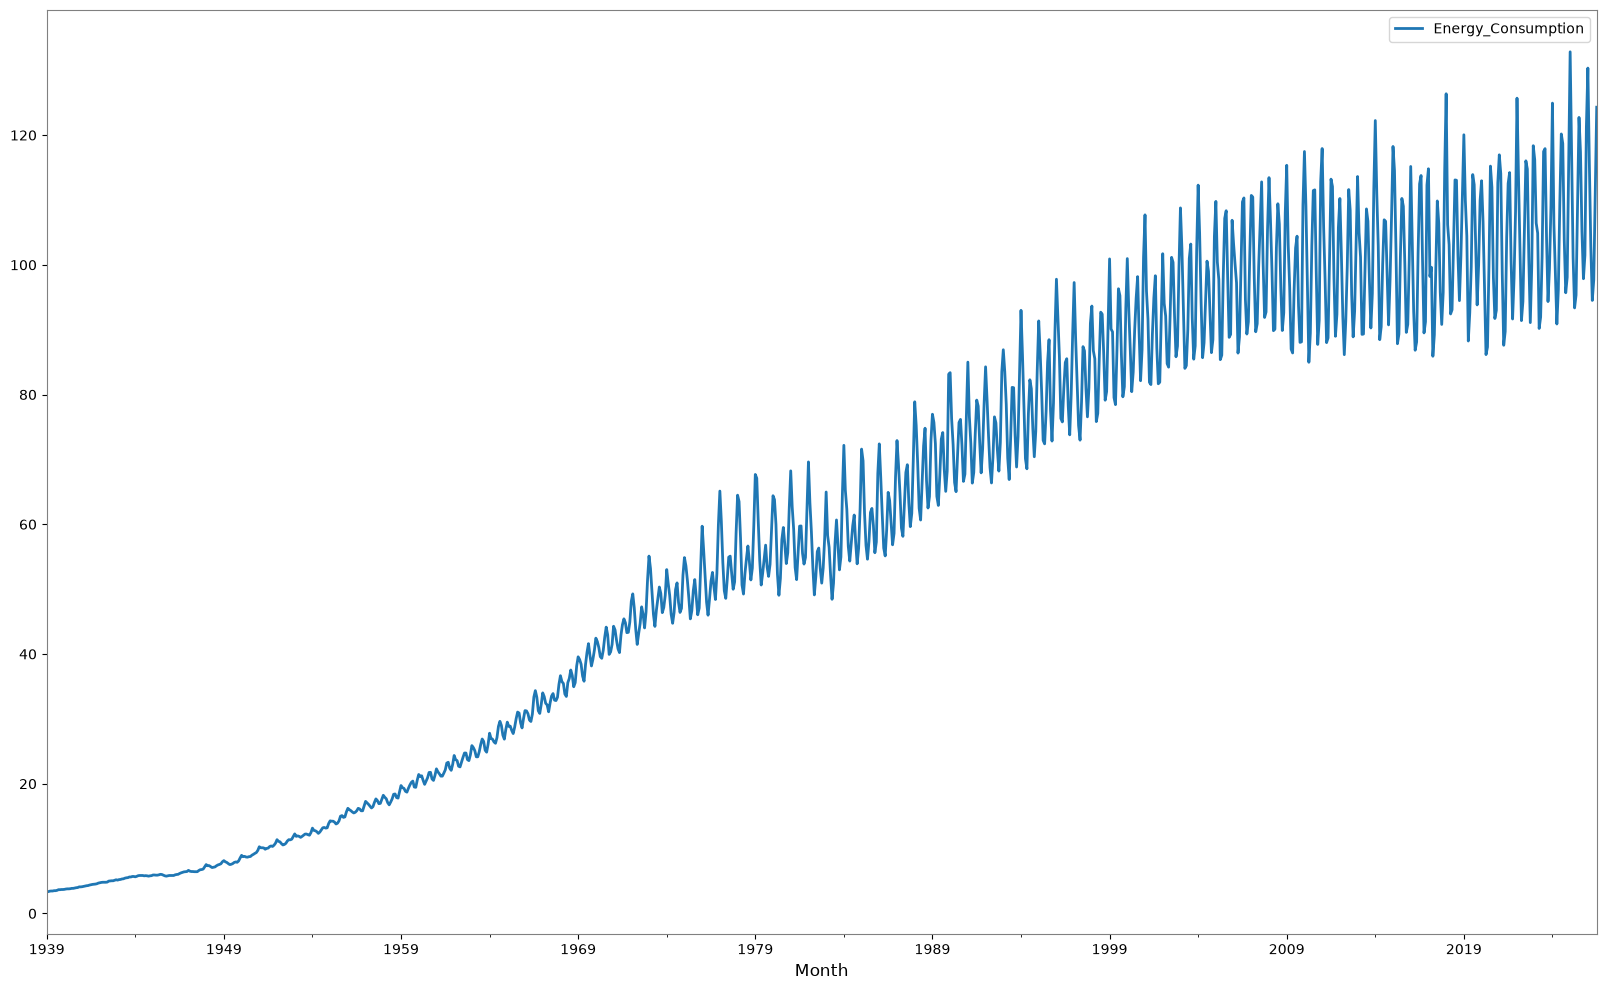

In [18]:
#TIME SERIES TREND ANALYSIS

#Plot the time series
df_series.plot(figsize=(20,12))
plt.show()

In [19]:
# We observe seasonality and a trend : both are easy to expect since its power consumption
# We can 

<function matplotlib.pyplot.show(close=None, block=None)>

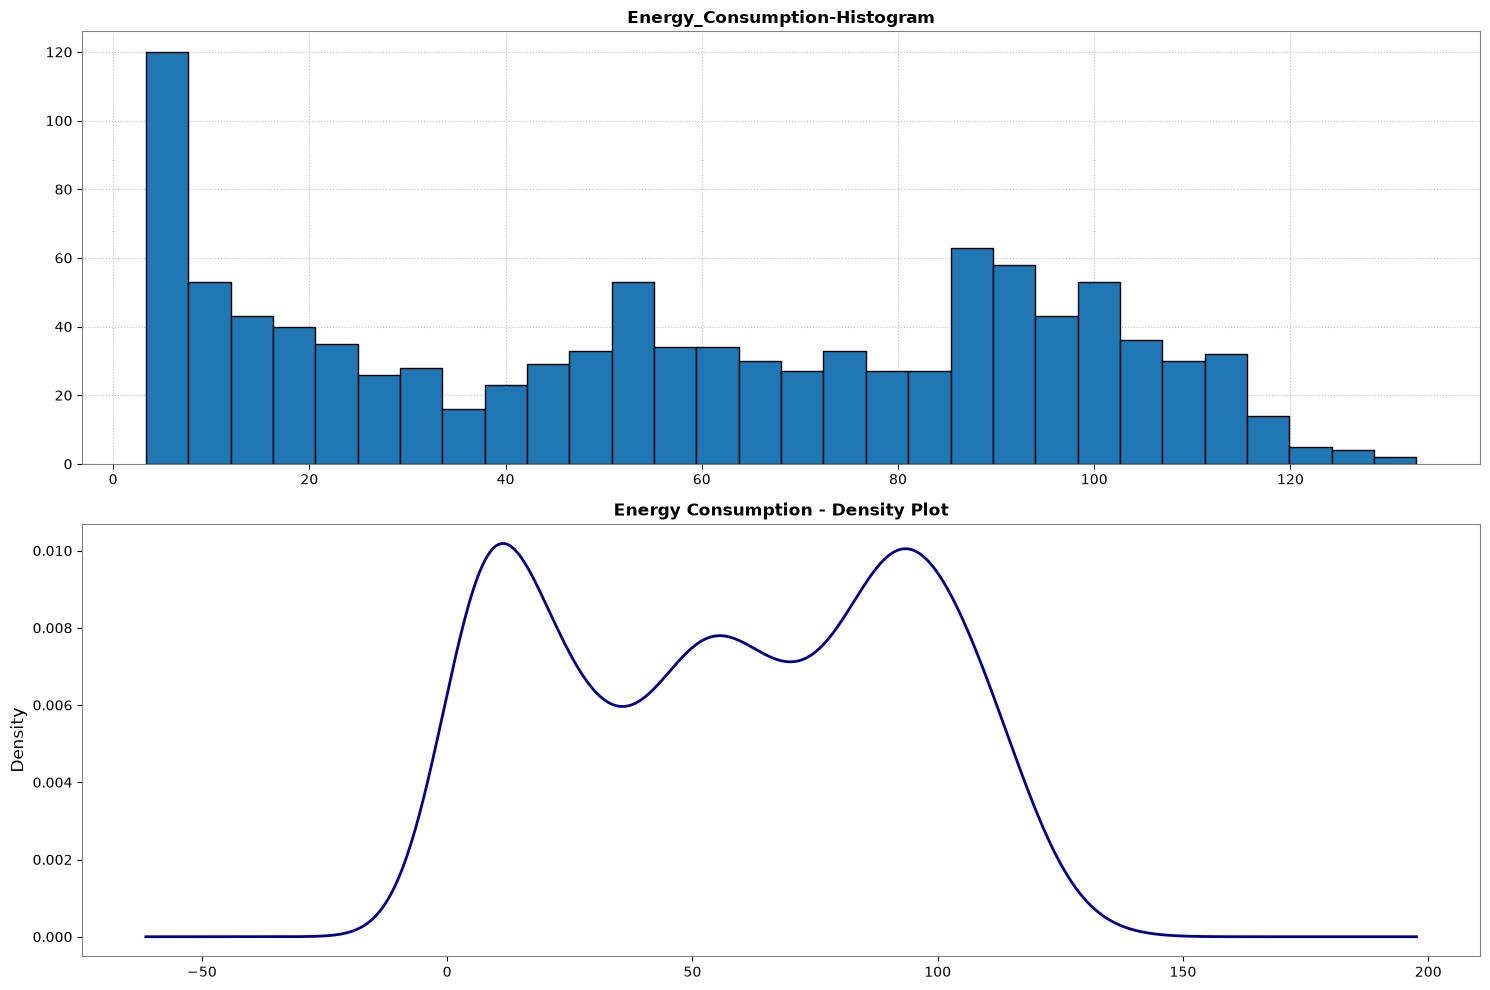

In [20]:
#Density anylysis for E_Consumption
plt.figure(figsize=(15,10))
#Histogram to visualize frequency distribution 
plt.subplot(2,1,1)
df_series['Energy_Consumption'].hist(bins=30,edgecolor='black')
plt.title('Energy_Consumption-Histogram')

#Distribution shape analysis
plt.subplot(2,1,2)
df_series['Energy_Consumption'].plot(kind='kde',linewidth=2,color='darkblue')
plt.title('Energy Consumption - Density Plot')
plt.tight_layout()
plt.show

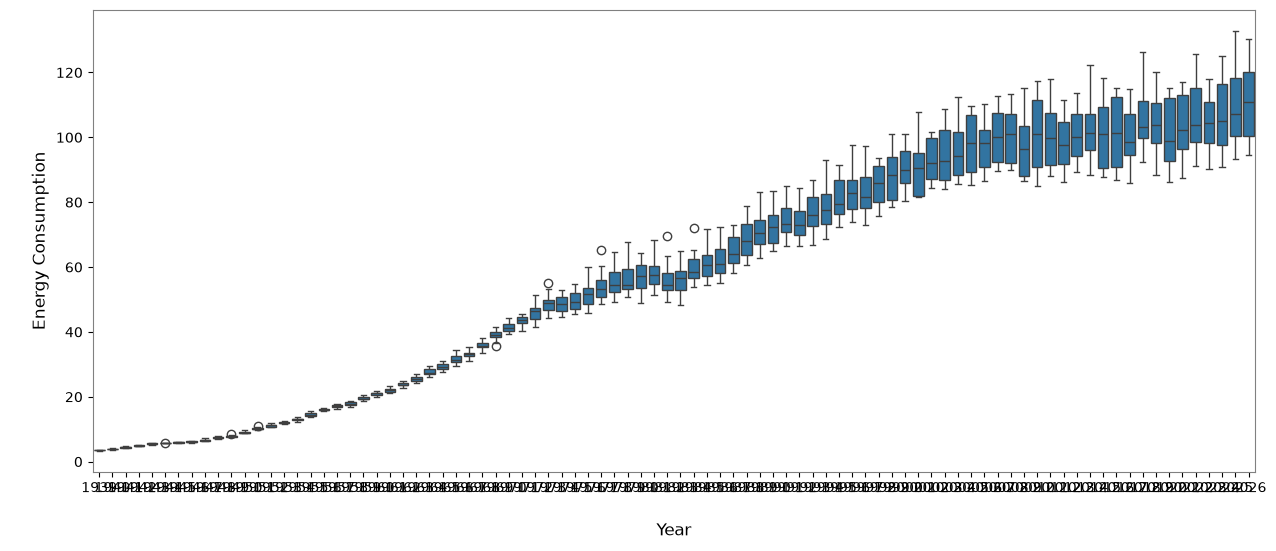

In [21]:
# BOX PLOT FOR EACH PERIOD IN THE SERIES 

fig, ax=plt.subplots(figsize=(15,6))
year_index = df_series.index.year
energy_values = df_series['Energy_Consumption']
sns.boxplot(x=year_index, y=energy_values, ax = ax)
plt.xlabel("\nYear")
plt.ylabel("\nEnergy Consumption")
plt.show()


In [22]:
#TIME SERIE DECOMPOSITION 
#Lets see which decomposition is the best between the additive and the multiplicative one 
decomposition_multiplicative = sm.tsa.seasonal_decompose(df_series,model='multiplicative',extrapolate_trend='freq')
#We are storing the decomposition in an object 


C:\Users\hugop\AppData\Local\Temp\ipykernel_6784\3209771207.py:3: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomposition_multiplicative = sm.tsa.seasonal_decompose(df_series,model='multiplicative',extrapolate_trend='freq')


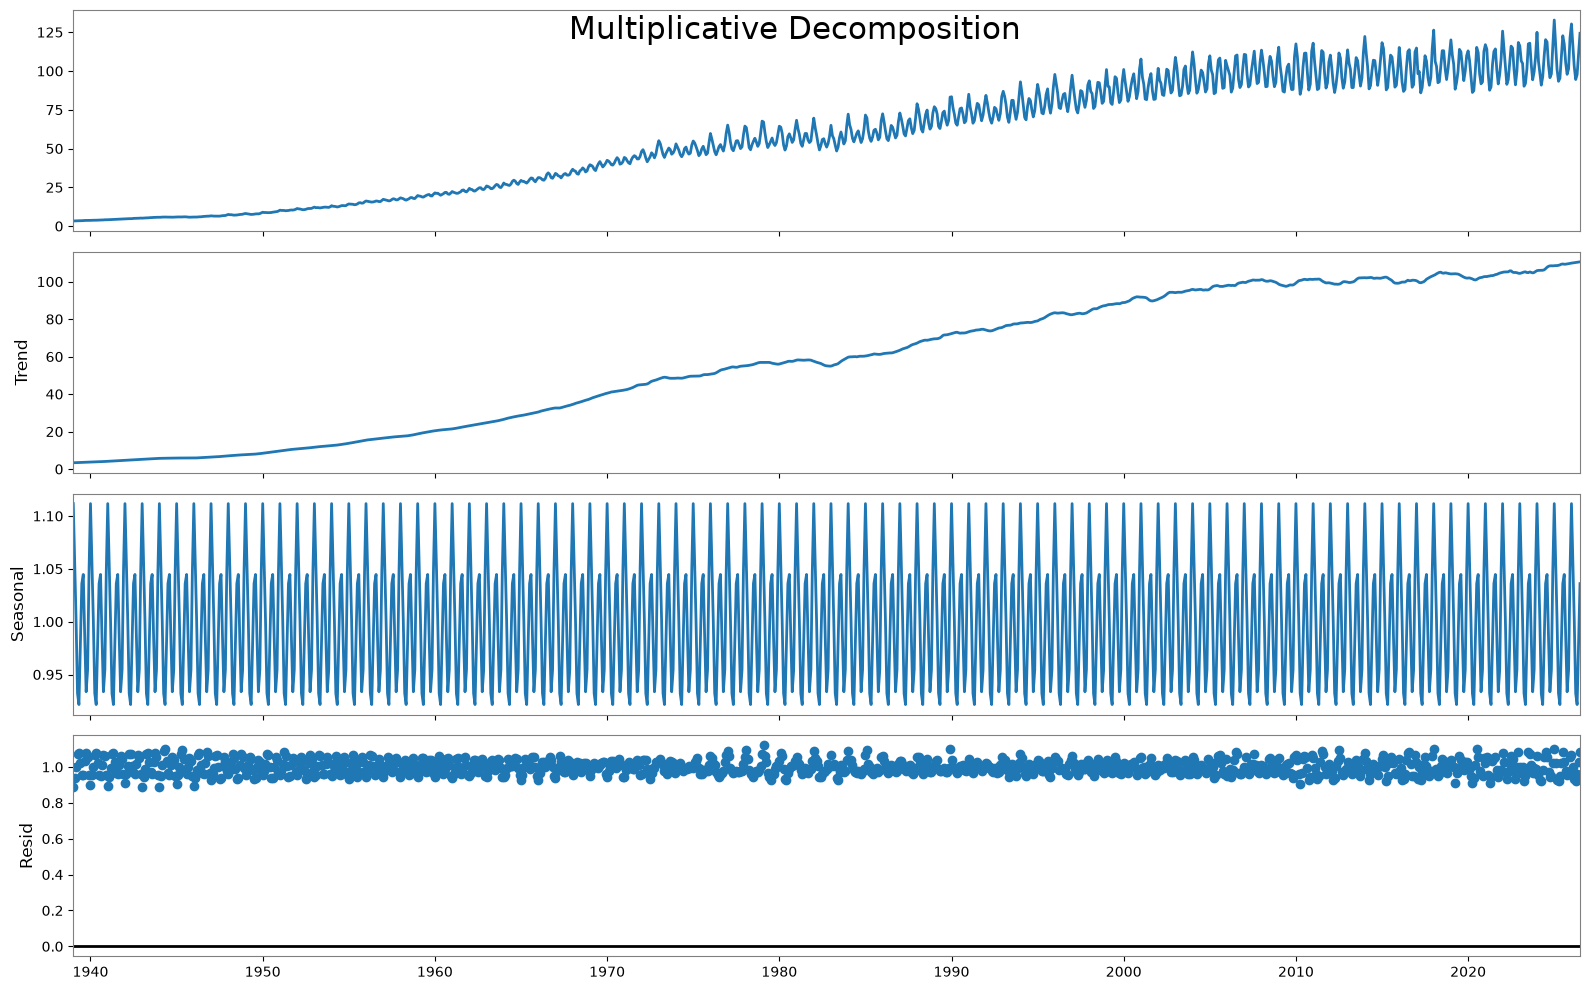

In [23]:
plt.rcParams.update({'figure.figsize': (16, 10)})

decomposition_multiplicative.plot().suptitle('Multiplicative Decomposition', 
fontsize=22)

plt.show()

In [24]:
#Original series
#Trend
#Seasonality
#Residuals

#Additive decomposition 
decomposition_additive = sm.tsa.seasonal_decompose(
    df_series, model='additive', extrapolate_trend='freq'
)

type(decomposition_additive)

C:\Users\hugop\AppData\Local\Temp\ipykernel_6784\1247338718.py:7: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomposition_additive = sm.tsa.seasonal_decompose(


statsmodels.tsa.seasonal._seasonal.DecomposeResult

<Figure size 1600x1000 with 0 Axes>

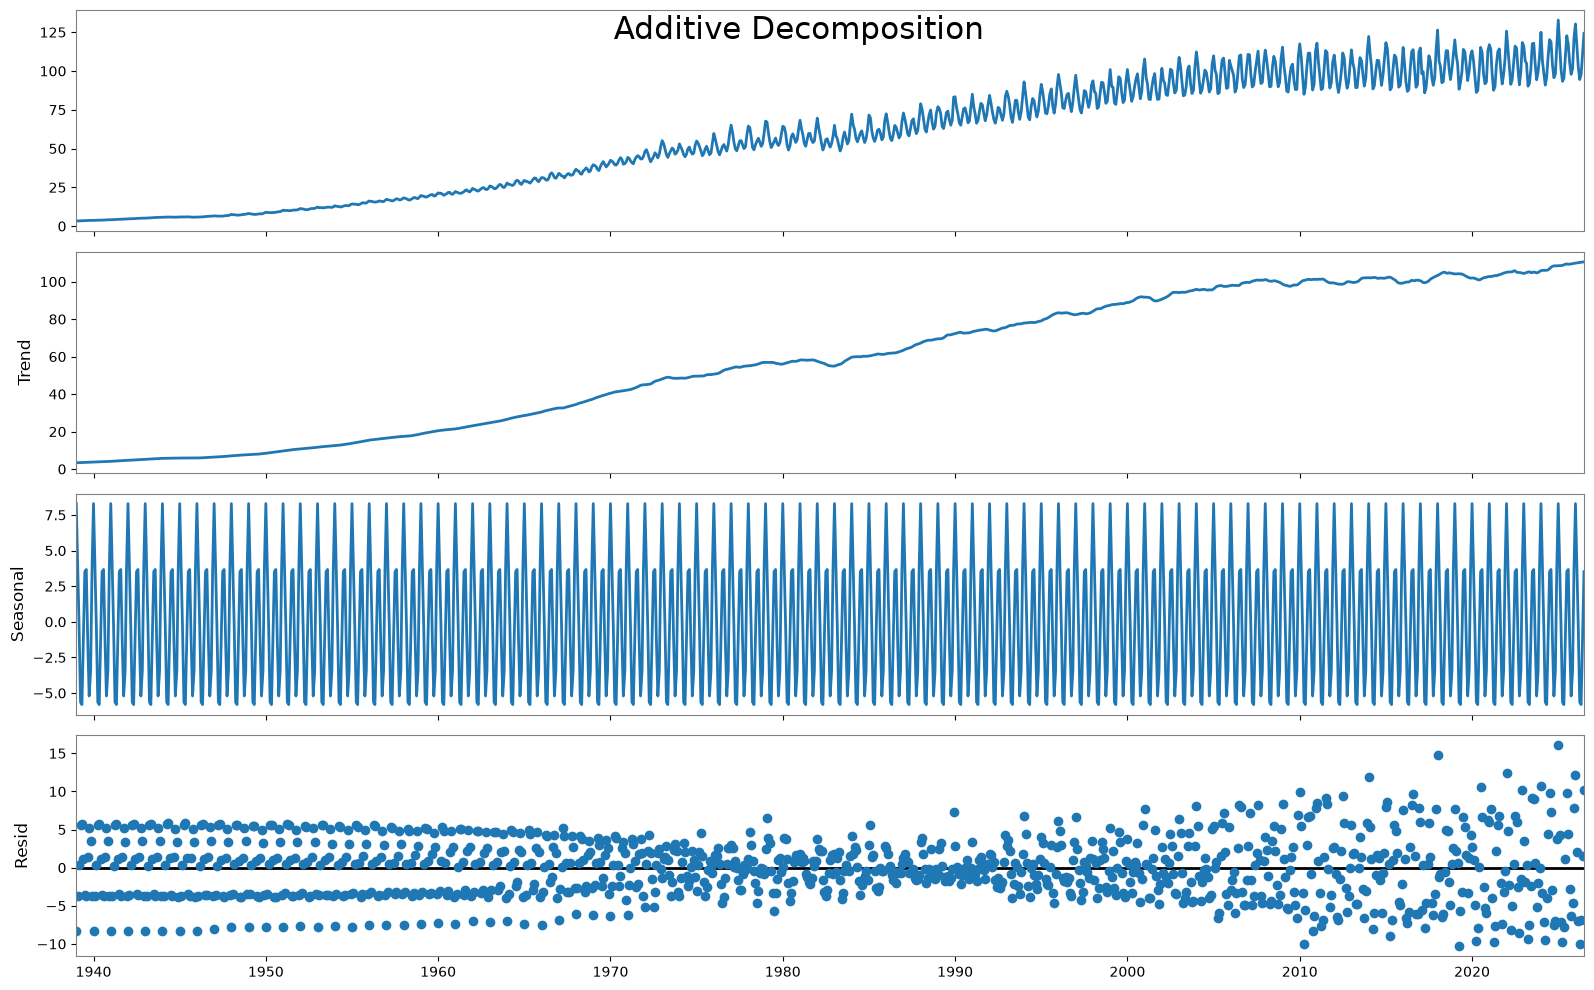

In [25]:
plt.figure(figsize=(16, 10))

fig = decomposition_additive.plot()
fig.suptitle('Additive Decomposition', fontsize=22)
plt.show()

In [26]:
# A test on the correlation and heteroscédasticity of the residual values should be done here 


In [27]:
#EXtracting time seriess componenents 
df_series_reconstructed = pd.concat(
    [
        decomposition_multiplicative.seasonal,  # Seasonal component
        decomposition_multiplicative.trend,     # Trend component
        decomposition_multiplicative.resid,     # Residual (noise) component
        decomposition_multiplicative.observed   # Observed (original) time series
    ], axis=1
)

In [28]:
df_series_reconstructed.columns = ['Seasonality', 'Trend', 'Residuals', 'Observed_Values']

df_series_reconstructed.head()

,Seasonality,Trend,Residuals,Observed_Values
Month,,,,
1939-01-01,1.111684,3.371515,0.889420,3.3336
1939-02-01,1.053031,3.400958,0.937952,3.3591
1939-03-01,1.002046,3.430400,0.999413,3.4354
1939-04-01,0.932112,3.459842,1.073129,3.4608
1939-05-01,0.921599,3.489284,1.076212,3.4608


In [29]:
observed_value =1.111684*3.371515*0.889420
print(observed_value)

3.333598885938269


In [30]:
#Statistical Assumptions
#Autocorrelation ? Statioonarity? normal distribution  ? 


# Stationarity ? 
type(df_series)

pandas.DataFrame

In [31]:
rolling_mean = df_series['Energy_Consumption'].rolling(
    window=12).mean()


rolling_std = df_series['Energy_Consumption'].rolling(
    window=12).std()

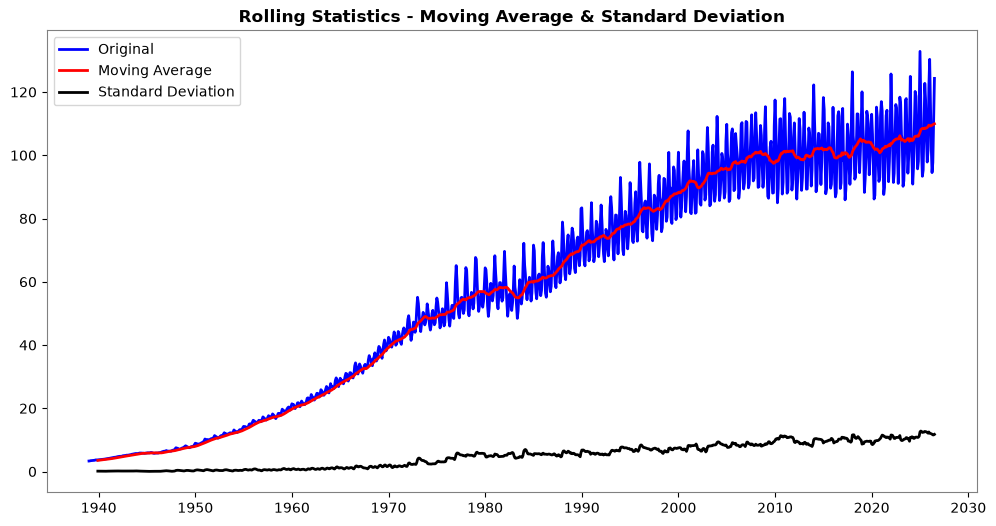

In [32]:
# 31. Plot rolling statistics for trend and variance analysis
plt.figure(figsize=(12, 6))

# 31.a Plot original time series values
plt.plot(df_series['Energy_Consumption'], color='blue', label='Original')

# 31.b Plot moving average (rolling mean)
plt.plot(rolling_mean, color='red', label='Moving Average')

# 31.c Plot rolling standard deviation
plt.plot(rolling_std, color='black', label='Standard Deviation')

# 31.d Configure legend and title
plt.legend(loc='best')
plt.title('Rolling Statistics - Moving Average & Standard Deviation')
plt.show()

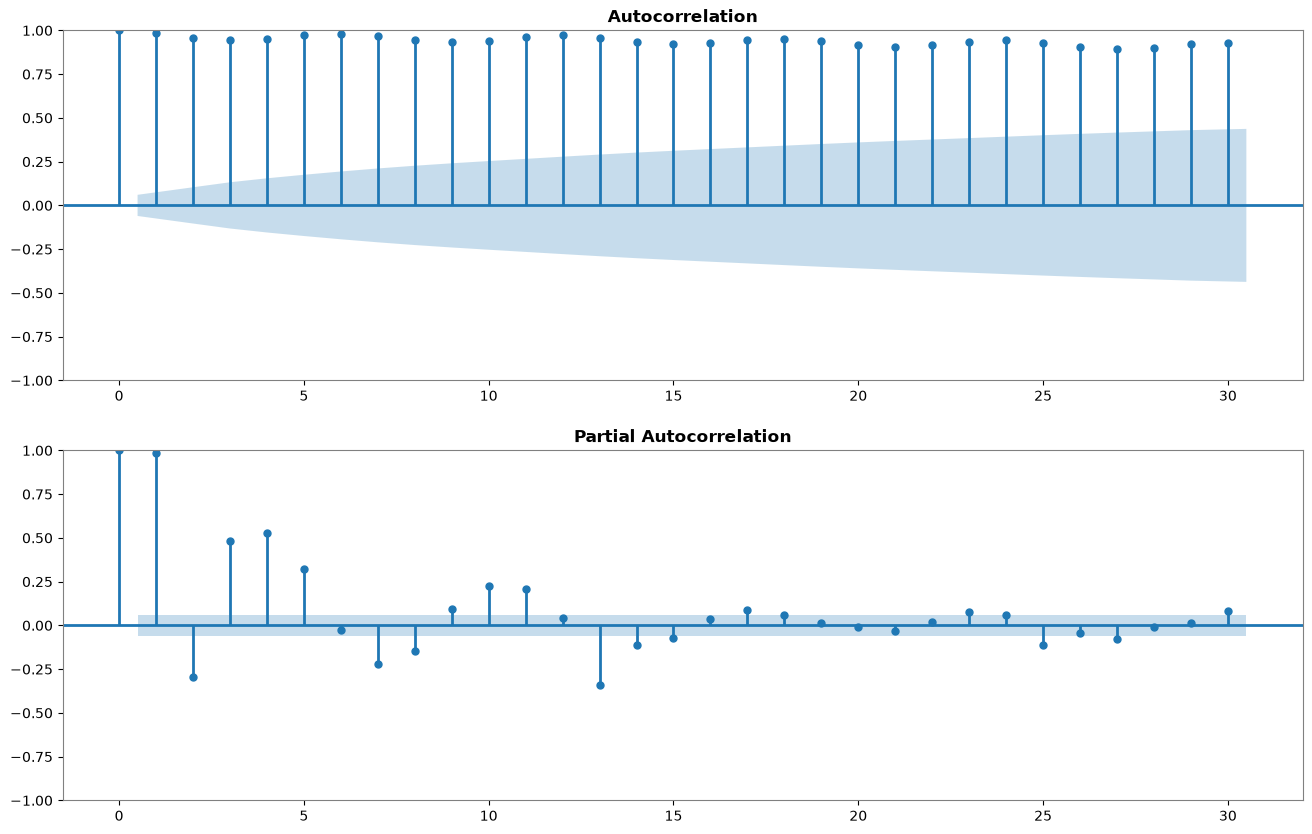

In [33]:
#Autocorrelation check 
# ACF = AUtocorrelation function 
#PACF = Partial Autocorrelation Function 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({'figure.figsize': (16, 10)})

plt.subplot(2, 1, 1)

plot_acf(df_series['Energy_Consumption'], 
         ax=plt.gca(), lags=30)

plt.subplot(2, 1, 2)

plot_pacf(df_series['Energy_Consumption'], 
          ax=plt.gca(), lags=30, method='ywm')

plt.show()

In [34]:
#we observe BIG autocorrelation 

In [35]:
# Stationary test : Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller


print('\\nDickey-Fuller Test Results:\\n')
adf_test = adfuller(df_series['Energy_Consumption'], 
                     autolag='AIC')

df_output = pd.Series(adf_test[0:4], index=[
    'Test Statistic', 'p-value', 
    'Lags Used', 'Observations Used'])

for key, value in adf_test[4].items():
    df_output[f'Critical Value ({key})'] = value

print(df_output)

\nDickey-Fuller Test Results:\n
Test Statistic            -0.550283
p-value                    0.881825
Lags Used                 22.000000
Observations Used       1028.000000
Critical Value (1%)       -3.436727
Critical Value (5%)       -2.864356
Critical Value (10%)      -2.568269
dtype: float64


C:\Users\hugop\AppData\Local\Temp\ipykernel_6784\499616026.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(df_series['Energy_Consumption'],


In [36]:
#p-value of 0,88 dff of 0,05 
# We can also automate the test : 


In [37]:
#Log-transformation 
df_series['Energy_Consumption_Log'] = np.log(
    df_series['Energy_Consumption'])

df_series.head()

,Energy_Consumption,Energy_Consumption_Log
Month,,
1939-01-01,3.3336,1.204053
1939-02-01,3.3591,1.211673
1939-03-01,3.4354,1.234133
1939-04-01,3.4608,1.241500
1939-05-01,3.4608,1.241500


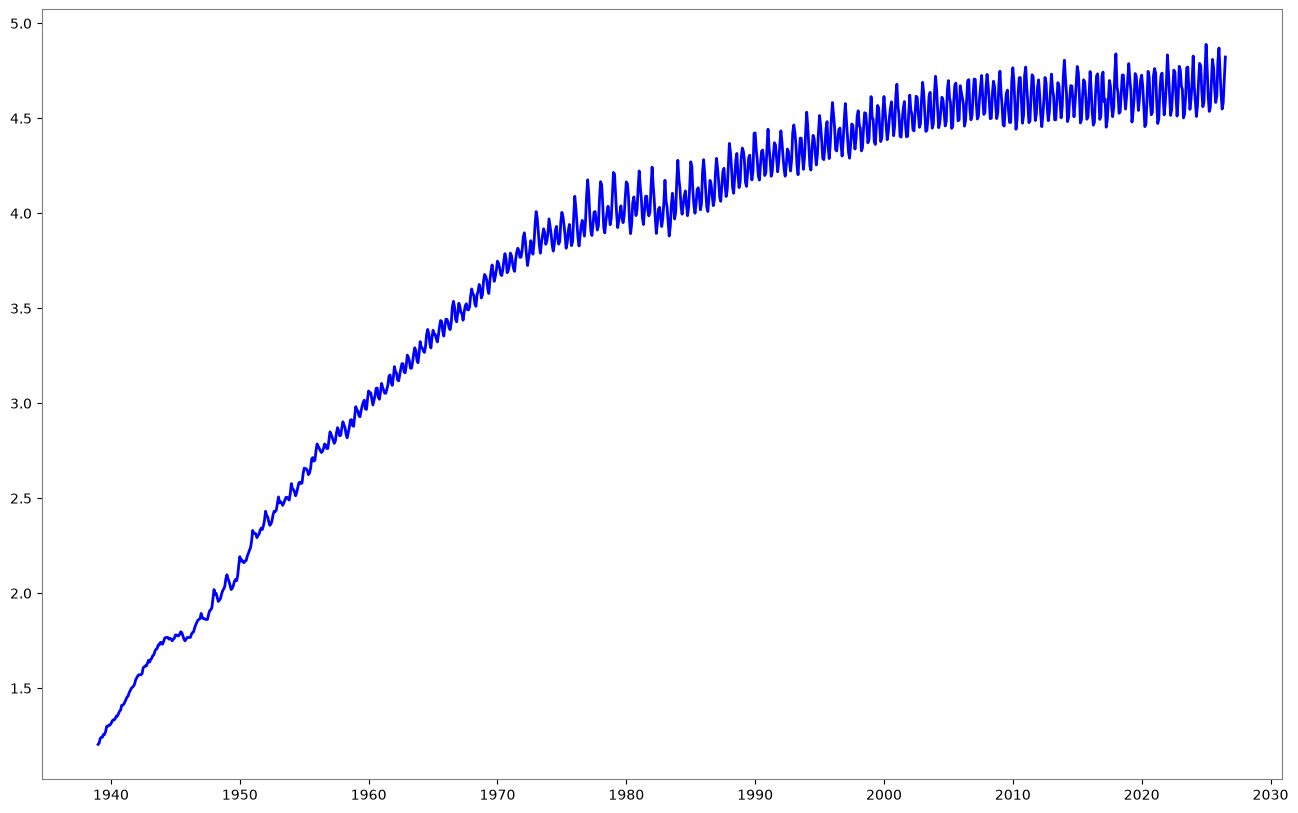

In [38]:
plt.plot(df_series['Energy_Consumption_Log'], 
         color="blue")


(array([ 41.,  66.,  39.,  53.,  59.,  66.,  69., 173., 241., 244.]),
 array([1.2040528 , 1.57256439, 1.94107599, 2.30958758, 2.67809917,
        3.04661077, 3.41512236, 3.78363395, 4.15214555, 4.52065714,
        4.88916873]),
 <BarContainer object of 10 artists>)

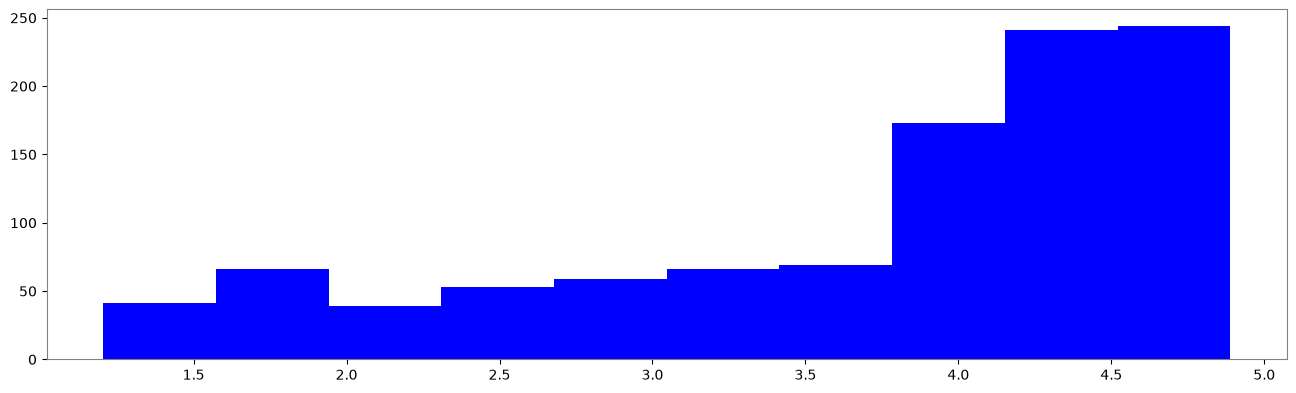

In [39]:
plt.subplot (2,1,1)
plt.hist(df_series['Energy_Consumption_Log'],color="blue")

In [40]:
def test_stationarity(series):

    #Import test
    from statsmodels.tsa.stattools import adfuller
    
    rolling_mean = series.rolling(12).mean()
    rolling_std = series.rolling(12).std()
    
    #rolling statistics
    plt.figure(figsize=(12, 6))
    plt.plot(series, color='blue', label='Original')
    plt.plot(rolling_mean, color='red', label='Moving Avg')
    plt.plot(rolling_std, color='black', label='Std Dev')
    plt.legend(loc='best')
    plt.title('Rolling Statistics')
    plt.show()
    
    #Dickey-Fuller test
    print("\nDickey-Fuller Test Results:\n")
    adf_test = adfuller(series, autolag='AIC')
    df_output = pd.Series(adf_test[0:4], index=[
        'Test Statistic', 'p-value', 
        'Lags Used', 'Observations Used'])
    
    #critical values
    for key, value in adf_test[4].items():
        df_output[f'Critical Value ({key})'] = value
    print(df_output)
    
    print("\nConclusion:")
    if df_output['p-value'] > 0.05:
        print("\nThe p-value is > 0.05, failing to reject H₀.")
        print("The series is likely non-stationary.")
    else:
        print("\nThe p-value is < 0.05, rejecting H₀.")
        print("The series is likely stationary.")



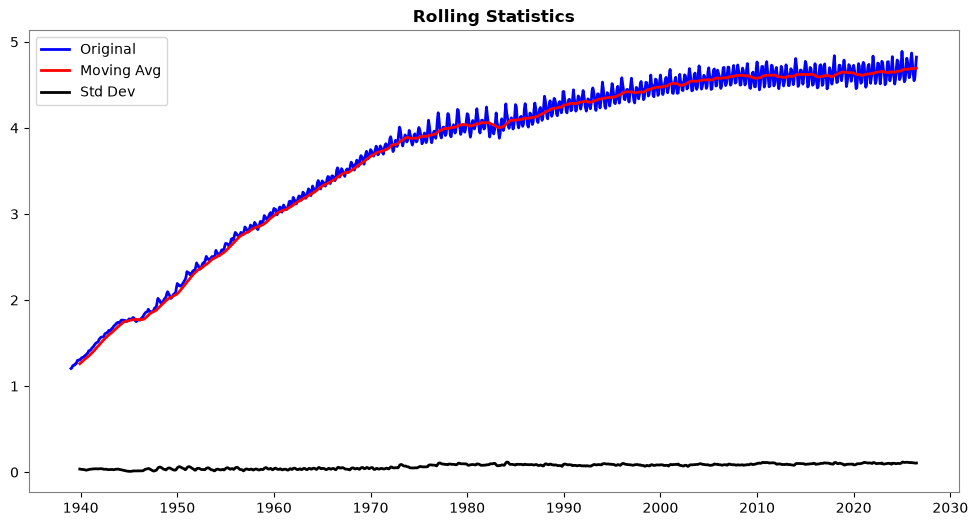


Dickey-Fuller Test Results:

Test Statistic         -6.512762e+00
p-value                 1.090013e-08
Lags Used               2.200000e+01
Observations Used       1.028000e+03
Critical Value (1%)    -3.436727e+00
Critical Value (5%)    -2.864356e+00
Critical Value (10%)   -2.568269e+00
dtype: float64

Conclusion:

The p-value is < 0.05, rejecting H₀.
The series is likely stationary.


C:\Users\hugop\AppData\Local\Temp\ipykernel_6784\2968590447.py:20: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(series, autolag='AIC')


In [41]:
test_stationarity(df_series['Energy_Consumption_Log'])

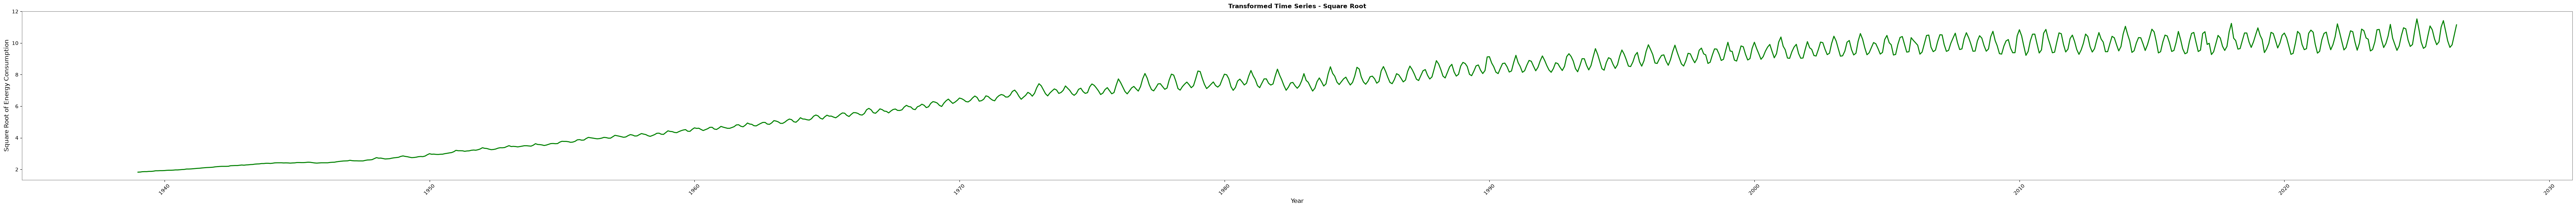

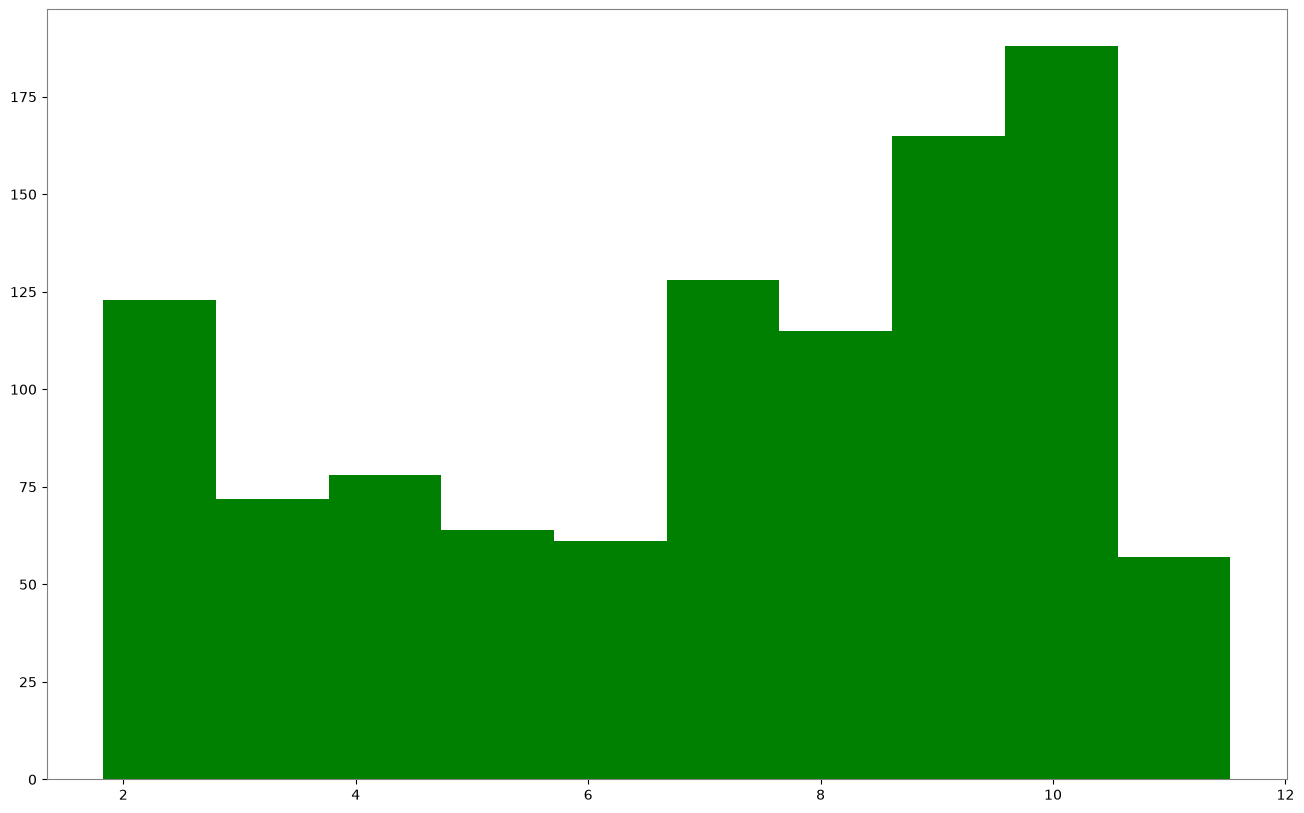

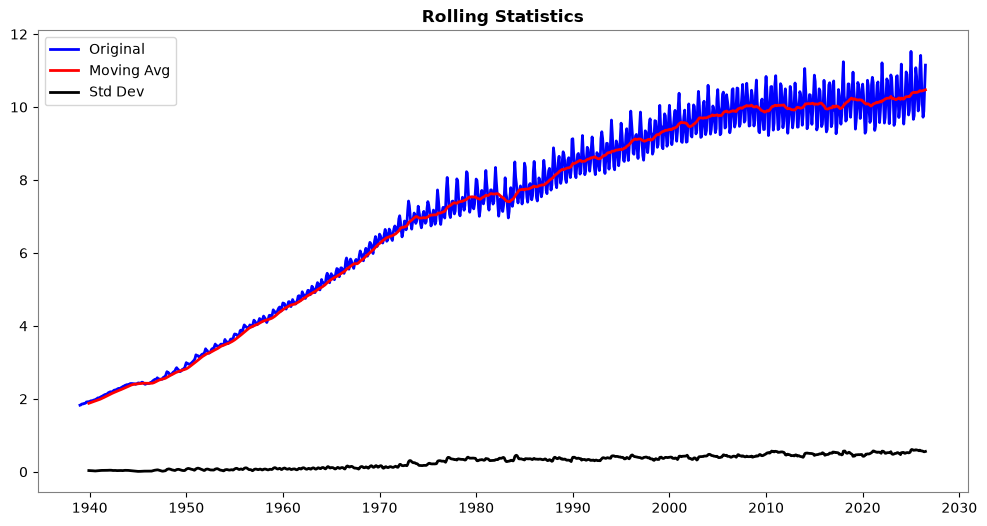


Dickey-Fuller Test Results:

Test Statistic            -3.508502
p-value                    0.007771
Lags Used                 22.000000
Observations Used       1028.000000
Critical Value (1%)       -3.436727
Critical Value (5%)       -2.864356
Critical Value (10%)      -2.568269
dtype: float64

Conclusion:

The p-value is < 0.05, rejecting H₀.
The series is likely stationary.


C:\Users\hugop\AppData\Local\Temp\ipykernel_6784\2968590447.py:20: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(series, autolag='AIC')


In [45]:
# SQUARE ROOT TRANSFO
df_series['Energy_Consumption_Sqrt'] = np.sqrt(df_series['Energy_Consumption'])
plt.figure(figsize=(90,6))
plt.plot(df_series.index,df_series['Energy_Consumption_Sqrt'],color="green")
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Square Root of Energy Consumption")
plt.title("Transformed Time Series - Square Root")
plt.show()
plt.hist(df_series['Energy_Consumption_Sqrt'],color="green")
plt.show()
test_stationarity(df_series['Energy_Consumption_Sqrt'])